In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
df = pd.read_csv('Iris.csv')

In [14]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [15]:
#dropping the id column
df = df.iloc[:, 1:]

In [16]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [17]:
#useing label encoding for target column
from sklearn.preprocessing import LabelEncoder

In [18]:
encode = LabelEncoder()

In [19]:
df['Species'] = encode.fit_transform(df['Species'])

In [20]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [21]:
#to make complex, we only take sepalwidth, petallength & species and also drop species == 0
df = df[df['Species'] != 0][['SepalWidthCm', 'PetalLengthCm', 'Species']]

In [22]:
df.head()

,SepalWidthCm,PetalLengthCm,Species
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1


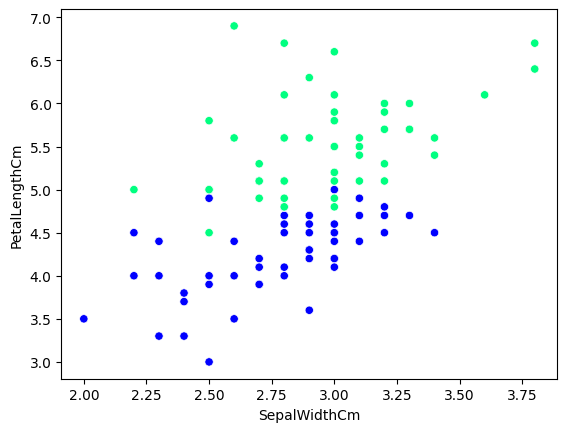

In [25]:
sns.scatterplot(x=df['SepalWidthCm'], y=df['PetalLengthCm'], c = df['Species'], cmap='winter')
plt.show()

In [26]:
df.shape

(100, 3)

In [27]:
df = df.sample(100) #shuffling the data

In [28]:
df_train = df.iloc[:60, :].sample(10)
df_val = df.iloc[60:80, :].sample(5)
df_test = df.iloc[80:, :].sample(5)

In [29]:
df_val

,SepalWidthCm,PetalLengthCm,Species
71,2.8,4.0,1
56,3.3,4.7,1
145,3.0,5.2,2
96,2.9,4.2,1
104,3.0,5.8,2


In [30]:
X_test = df_val.iloc[:, 0:2].values
y_test = df_val.iloc[:, -1].values

In [31]:
y_test

array([1, 1, 2, 1, 2])

**Bagging**

In [32]:
df_bag = df_train.sample(8, replace= True)
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

In [33]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
from mlxtend.plotting import plot_decision_regions

In [34]:
dt_bag1 = DecisionTreeClassifier()

In [36]:
def evaluate(clf, X, y):
    clf.fit(X, y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values, y.values, clf=clf, legend=2)
    y_pred = clf.predict(X_test)
    print("accuracy score: ", accuracy_score(y_test, y_pred))

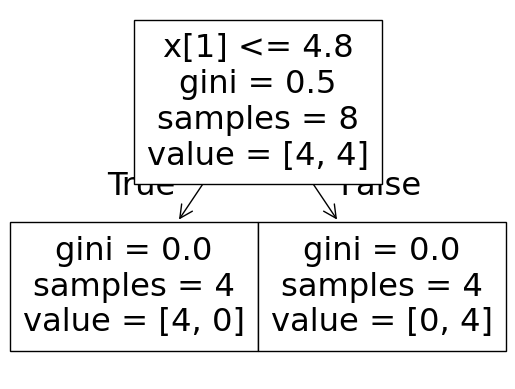

C:\Users\Lenovo\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


accuracy score:  1.0


C:\Users\Lenovo\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


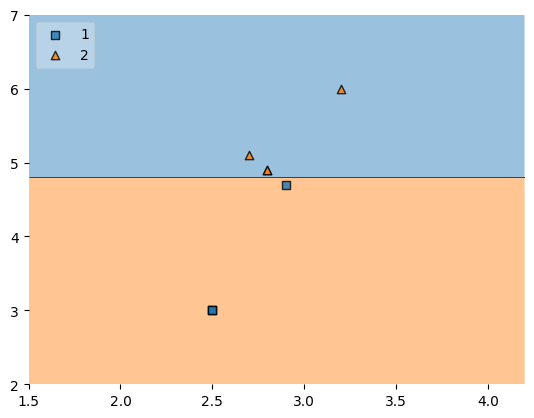

In [37]:
evaluate(dt_bag1, X, y)

In [38]:
df_bag = df_train.sample(8, replace= True)
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

In [41]:
df_bag

,SepalWidthCm,PetalLengthCm,Species
63,2.9,4.7,1
99,2.8,4.1,1
98,2.5,3.0,1
148,3.4,5.4,2
101,2.7,5.1,2
121,2.8,4.9,2
99,2.8,4.1,1
121,2.8,4.9,2


In [39]:
dt_bag2 = DecisionTreeClassifier()

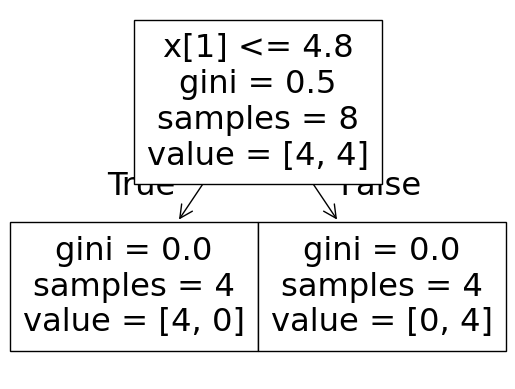

C:\Users\Lenovo\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\Lenovo\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


accuracy score:  1.0


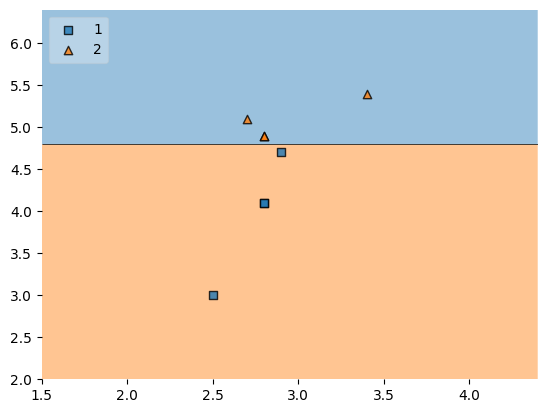

In [40]:
evaluate(dt_bag2, X, y)

In [42]:
df_bag = df_train.sample(8, replace= True)
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

In [43]:
df_bag

,SepalWidthCm,PetalLengthCm,Species
125,3.2,6.0,2
72,2.5,4.9,1
121,2.8,4.9,2
78,2.9,4.5,1
98,2.5,3.0,1
63,2.9,4.7,1
72,2.5,4.9,1
99,2.8,4.1,1


In [44]:
dt_bag3 = DecisionTreeClassifier()

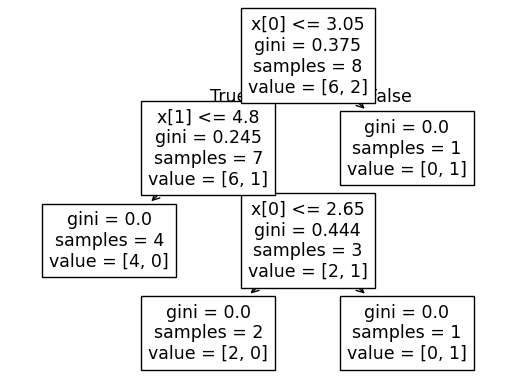

accuracy score:  0.8


C:\Users\Lenovo\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\Lenovo\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


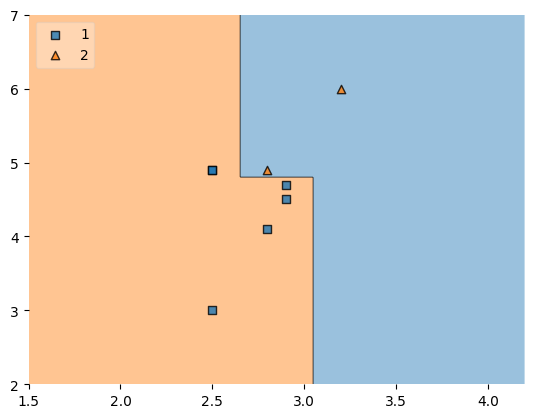

In [45]:
evaluate(dt_bag3, X, y)

**Predict: Aggregration part**

In [46]:
df_test

,SepalWidthCm,PetalLengthCm,Species
69,2.5,3.9,1
83,2.7,5.1,1
106,2.5,4.5,2
110,3.2,5.1,2
139,3.1,5.4,2


In [49]:
print("predictor 1", dt_bag1.predict(np.array([3.1, 5.4]).reshape(1, 2)))
print('predictor 2', dt_bag2.predict(np.array([3.1, 5.4]).reshape(1, 2)))
print("predictor 3", dt_bag3.predict(np.array([3.1, 5.4]).reshape(1, 2)))

predictor 1 [2]
predictor 2 [2]
predictor 3 [2]


C:\Users\Lenovo\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\Lenovo\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\Lenovo\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


**Types of bagging**


**1. Pasting**

row sampling without replacement.

**2. Random subspaces**

In random subspaces, we do column sampling. (can be done with replacement or without replacement)

In [50]:
#eg
df1 = pd.read_csv('Iris.csv')

In [51]:
df1.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [53]:
#random subspaces
df1.sample(2, replace=True, axis=1)

,Id,SepalWidthCm
0,1,3.5
1,2,3.0
2,3,3.2
3,4,3.1
4,5,3.6
...,...,...
145,146,3.0
146,147,2.5
147,148,3.0
148,149,3.4


**3. Random Patches**

In random patches, you do both row and column sampling

In [56]:
#example
df1.sample(8, replace=True).sample(3, replace=True, axis=1)

,SepalWidthCm,PetalLengthCm,PetalLengthCm
56,3.3,4.7,4.7
2,3.2,1.3,1.3
120,3.2,5.7,5.7
86,3.1,4.7,4.7
90,2.6,4.4,4.4
58,2.9,4.6,4.6
65,3.1,4.4,4.4
60,2.0,3.5,3.5
